## Imports

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# EDA

In [9]:
df = pd.read_csv('enhanced_photovoltaic_data.csv')
df

,Timestamp,Solar_Irradiance,Temperature,Humidity,Wind_Speed,Panel_Angle,Energy_Output,Energy_Output_Class
0,2024-01-01 00:00:00,499.632095,19.530827,70.534191,12.621713,6.210683,117.090063,Low
1,2024-01-01 01:00:00,960.571445,16.662407,49.937520,7.069308,84.670607,478.957863,High
2,2024-01-01 02:00:00,785.595153,33.528016,88.132803,14.686574,45.622839,190.098226,Low
3,2024-01-01 03:00:00,678.926787,29.361828,25.943481,9.512132,36.847086,503.067447,High
4,2024-01-01 04:00:00,324.814912,36.045719,72.336336,1.893971,72.979072,506.471717,High
...,...,...,...,...,...,...,...,...
716,2024-01-30 20:00:00,864.495526,32.617019,50.531588,2.792038,12.710119,513.635143,High
717,2024-01-30 21:00:00,972.021529,20.046336,77.394370,4.973470,51.378968,395.824523,Medium
718,2024-01-30 22:00:00,299.437779,31.835811,68.603283,12.825453,16.674332,256.720403,Medium
719,2024-01-30 23:00:00,784.693980,39.247801,65.883571,3.106137,25.077876,448.445208,High


In [10]:
df.shape
df.head()
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 721 entries, 0 to 720
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Timestamp            721 non-null    str    
 1   Solar_Irradiance     721 non-null    float64
 2   Temperature          721 non-null    float64
 3   Humidity             721 non-null    float64
 4   Wind_Speed           721 non-null    float64
 5   Panel_Angle          721 non-null    float64
 6   Energy_Output        721 non-null    float64
 7   Energy_Output_Class  721 non-null    str    
dtypes: float64(6), str(2)
memory usage: 45.2 KB


,Timestamp,Solar_Irradiance,Temperature,Humidity,Wind_Speed,Panel_Angle,Energy_Output,Energy_Output_Class
count,721,721.000000,721.000000,721.000000,721.000000,721.000000,721.000000,721
unique,721,NaN,NaN,NaN,NaN,NaN,NaN,3
top,2024-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,Medium
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,299
mean,NaN,595.288152,27.510663,55.323721,7.435704,45.027416,280.918161,NaN
std,NaN,236.381197,7.366291,25.703327,4.370279,25.623069,144.766232,NaN
min,NaN,204.049267,15.115801,10.289644,0.002020,0.001047,16.246926,NaN
25%,NaN,391.649513,20.776870,32.701692,3.904303,22.580374,156.190606,NaN
50%,NaN,602.143219,27.647217,56.554215,7.333467,45.702456,272.898206,NaN
75%,NaN,801.899624,33.955962,77.394370,11.301419,66.412565,401.522059,NaN


## DQ Check

In [11]:
df.isna().sum().sort_values(ascending=False)

Timestamp              0
Solar_Irradiance       0
Temperature            0
Humidity               0
Wind_Speed             0
Panel_Angle            0
Energy_Output          0
Energy_Output_Class    0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.nunique().sort_values()

Energy_Output_Class      3
Timestamp              721
Solar_Irradiance       721
Temperature            721
Humidity               721
Wind_Speed             721
Panel_Angle            721
Energy_Output          721
dtype: int64

## 'Timestamp' Check

In [14]:
print(df["Timestamp"].min())
print(df["Timestamp"].max())
print(df["Timestamp"].duplicated().sum())

2024-01-01 00:00:00
2024-01-31 00:00:00
0


#### Check for time interval

In [16]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["Timestamp"].diff().value_counts().head(10)

Timestamp
0 days 01:00:00    720
Name: count, dtype: int64

Time interval is 1 hour

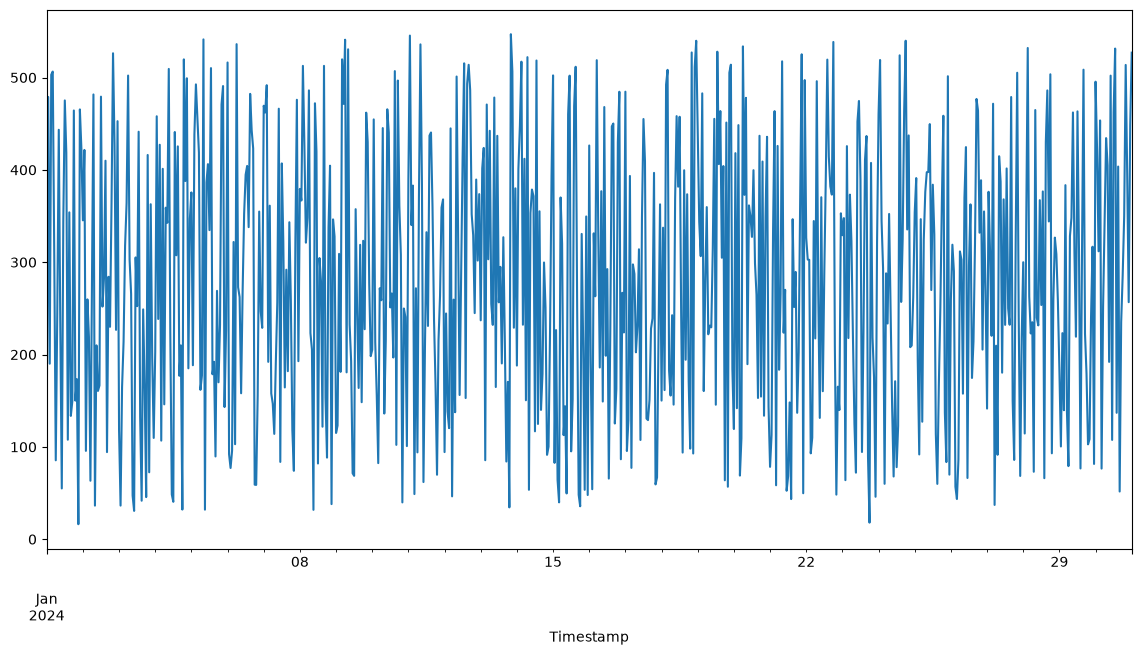

In [29]:
df.set_index("Timestamp")["Energy_Output"].plot(
    figsize=(14, 7)
)

plt.show()

## 'Panel_Angle' Check

In [30]:
df["Panel_Angle"].describe()

count    721.000000
mean      45.027416
std       25.623069
min        0.001047
25%       22.580374
50%       45.702456
75%       66.412565
max       89.900335
Name: Panel_Angle, dtype: float64

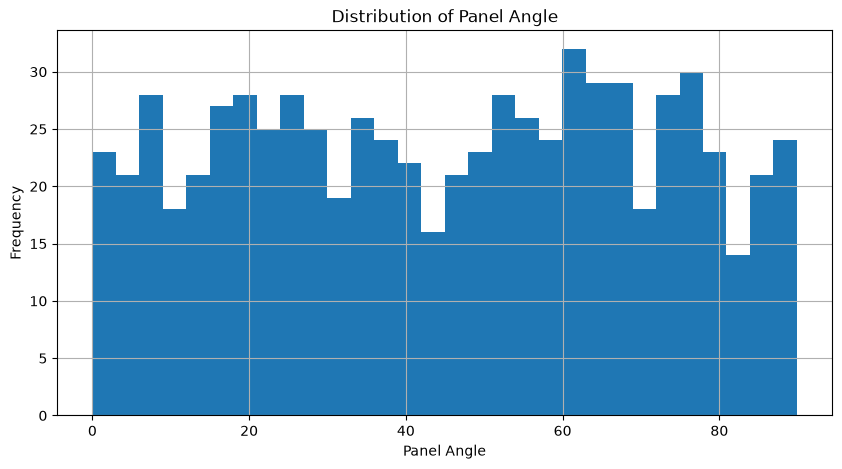

In [31]:
df["Panel_Angle"].hist(bins=30, figsize=(10, 5))
plt.xlabel("Panel Angle")
plt.ylabel("Frequency")
plt.title("Distribution of Panel Angle")
plt.show()

In [37]:
print(df[
    (df["Panel_Angle"] < 0) |
    (df["Panel_Angle"] > 90)
])

df["Panel_Angle"].min(), df["Panel_Angle"].max()

Empty DataFrame
Columns: [Timestamp, Solar_Irradiance, Temperature, Humidity, Wind_Speed, Panel_Angle, Energy_Output, Energy_Output_Class]
Index: []


(np.float64(0.0010471279829527), np.float64(89.90033508299615))

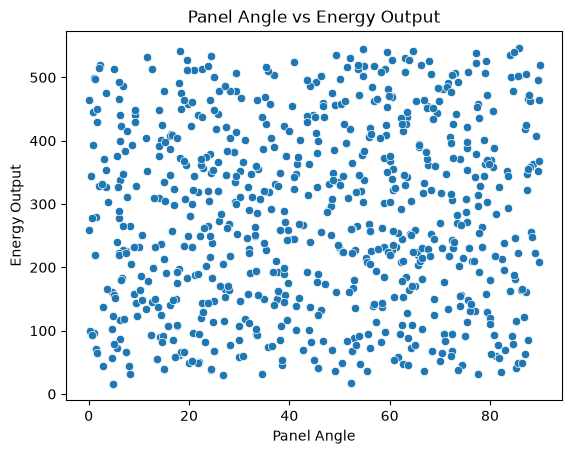

In [38]:
sns.scatterplot(
    data=df,
    x="Panel_Angle",
    y="Energy_Output"
)

plt.xlabel("Panel Angle")
plt.ylabel("Energy Output")
plt.title("Panel Angle vs Energy Output")
plt.show()

In [39]:
df["Angle_Bin"] = pd.cut(
    df["Panel_Angle"],
    bins=10
)

angle_output = df.groupby(
    "Angle_Bin",
    observed=True
)["Energy_Output"].mean()

print(angle_output)

Angle_Bin
(-0.0889, 8.991]    269.096930
(8.991, 17.981]     255.541366
(17.981, 26.971]    280.895762
(26.971, 35.961]    278.773277
(35.961, 44.951]    265.953900
(44.951, 53.941]    290.907262
(53.941, 62.931]    295.230923
(62.931, 71.92]     292.595738
(71.92, 80.91]      290.844265
(80.91, 89.9]       281.280288
Name: Energy_Output, dtype: float64


/var/folders/dp/6x6kw_mx5vn01r0dzmdrszw80000gn/T/ipykernel_61641/1513501076.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Panel_Angle"].dropna(), vert=False)


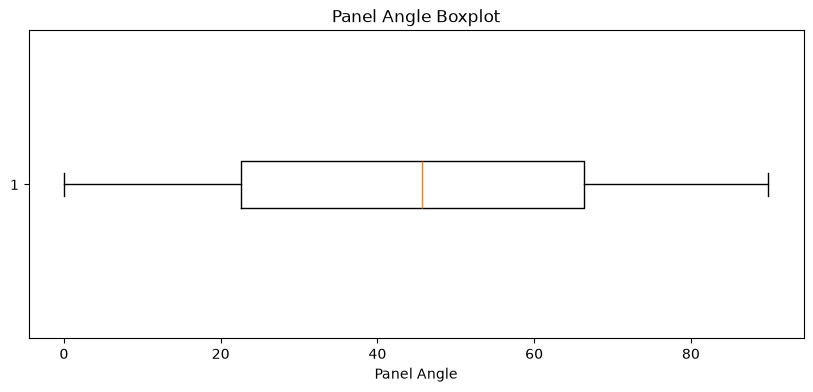

In [53]:
plt.figure(figsize=(10, 4))

plt.boxplot(df["Panel_Angle"].dropna(), vert=False)

plt.xlabel("Panel Angle")
plt.title("Panel Angle Boxplot")
plt.show()

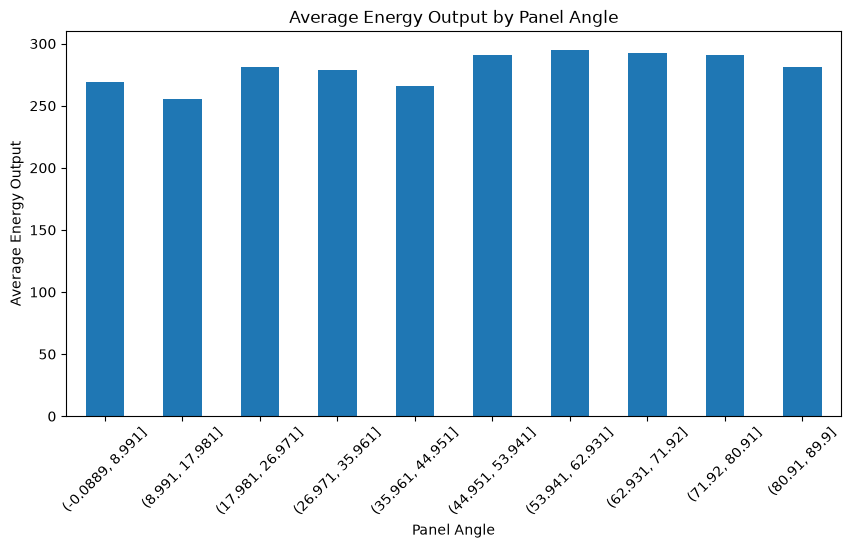

In [40]:
angle_output.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("Panel Angle")
plt.ylabel("Average Energy Output")
plt.title("Average Energy Output by Panel Angle")
plt.xticks(rotation=45)
plt.show()

## 'Energy_Output' Check

In [48]:
print(df["Energy_Output"].describe())
print("\n")
print(df["Energy_Output"].min())
print(df["Energy_Output"].max())
print(df["Energy_Output"].mean())
print(df["Energy_Output"].median())

count    721.000000
mean     280.918161
std      144.766232
min       16.246926
25%      156.190606
50%      272.898206
75%      401.522059
max      546.918747
Name: Energy_Output, dtype: float64


16.24692614546207
546.9187469502057
280.9181611256459
272.89820646182267


In [49]:
print("Missing:", df["Energy_Output"].isna().sum())
print("Zero:", (df["Energy_Output"] == 0).sum())
print("Negative:", (df["Energy_Output"] < 0).sum())

Missing: 0
Zero: 0
Negative: 0


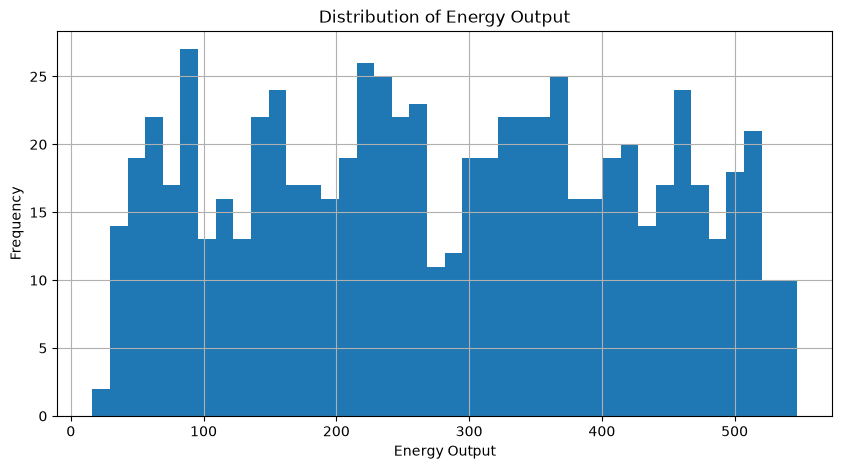

In [50]:
df["Energy_Output"].hist(bins=40, figsize=(10, 5))

plt.xlabel("Energy Output")
plt.ylabel("Frequency")
plt.title("Distribution of Energy Output")
plt.show()

/var/folders/dp/6x6kw_mx5vn01r0dzmdrszw80000gn/T/ipykernel_61641/3561019880.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Energy_Output"].dropna(), vert=False)


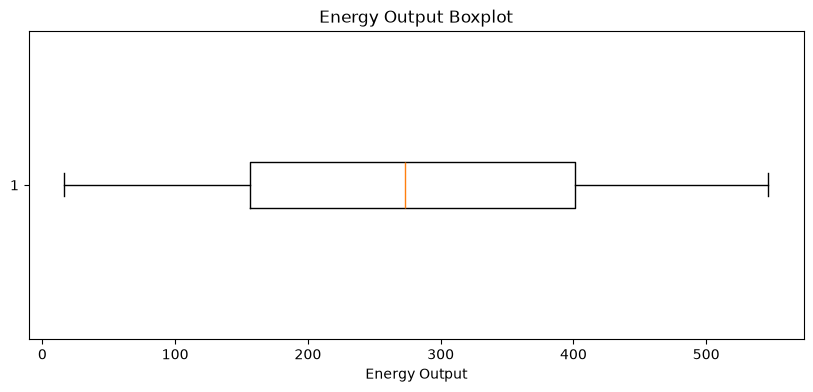

In [52]:
plt.figure(figsize=(10, 4))

plt.boxplot(df["Energy_Output"].dropna(), vert=False)

plt.xlabel("Energy Output")
plt.title("Energy Output Boxplot")
plt.show()

## 'Energy_Output_Class' Check

In [54]:
print(df["Energy_Output_Class"].value_counts())
print(df["Energy_Output_Class"].value_counts(normalize=True) * 100)

Energy_Output_Class
Medium    299
Low       239
High      183
Name: count, dtype: int64
Energy_Output_Class
Medium    41.470180
Low       33.148405
High      25.381415
Name: proportion, dtype: float64


In [55]:
df.groupby("Energy_Output_Class")["Energy_Output"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Energy_Output_Class,,,,,
High,183,469.073352,465.461089,401.055193,546.918747
Low,239,114.341215,114.063109,16.246926,198.702872
Medium,299,298.909767,303.163881,202.413560,399.637950


#### Irradiance vs Output

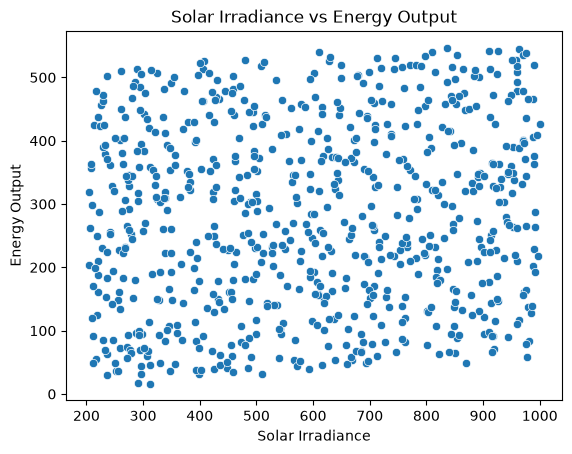

In [56]:
sns.scatterplot(
    data=df,
    x="Solar_Irradiance",
    y="Energy_Output"
)

plt.xlabel("Solar Irradiance")
plt.ylabel("Energy Output")
plt.title("Solar Irradiance vs Energy Output")
plt.show()

In [57]:
df[["Solar_Irradiance", "Energy_Output"]].corr()

,Solar_Irradiance,Energy_Output
Solar_Irradiance,1.000000,0.112093
Energy_Output,0.112093,1.000000


In [58]:
df[
    (df["Solar_Irradiance"] < 10) &
    (df["Energy_Output"] > 10)
]

,Timestamp,Solar_Irradiance,Temperature,Humidity,Wind_Speed,Panel_Angle,Energy_Output,Energy_Output_Class,Angle_Bin
